# Relación entre categoría y talla de los productos

En este notebook analizo si la distribución de las tallas cambia dependiendo de la categoría del producto. El objetivo es identificar si diferentes categorías presentan distintos patrones de demanda de tallas y qué podría significar esto para la planificación del inventario.

In [2]:
from pathlib import Path
import pandas as pd

rutas_dataset = [
    Path('../data/Amazon_Sales.csv'),
    Path('data/Amazon_Sales.csv')
]
ruta_dataset = next((ruta for ruta in rutas_dataset if ruta.exists()), None)
if ruta_dataset is None:
    raise FileNotFoundError('No se encontró data/Amazon_Sales.csv')

df = pd.read_csv(ruta_dataset)

print('Dimensiones:', df.shape)
print('\nValores de Category (frecuencia):')
print(df['Category'].value_counts(dropna=False))
print('\nValores de Size (frecuencia, incluidos faltantes):')
print(df['Size'].value_counts(dropna=False))
print('\nTipo y resumen de Qty:')
print(df['Qty'].dtype)
print(df['Qty'].describe())
print('Qty faltante:', df['Qty'].isna().sum())
print('Qty no numérica tras conversión:', pd.to_numeric(df['Qty'], errors='coerce').isna().sum() - df['Qty'].isna().sum())

Dimensiones: (128975, 22)

Valores de Category (frecuencia):
Category
Set              50284
kurta            49877
Western Dress    15500
Top              10622
Ethnic Dress      1159
Blouse             926
Bottom             440
Saree              164
Dupatta              3
Name: count, dtype: int64

Valores de Size (frecuencia, incluidos faltantes):
Size
M       22711
L       22132
XL      20876
XXL     18096
S       17090
3XL     14816
XS      11161
6XL       738
5XL       550
4XL       427
Free      378
Name: count, dtype: int64

Tipo y resumen de Qty:
int64
count    128975.000000
mean          0.904431
std           0.313354
min           0.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          15.000000
Name: Qty, dtype: float64
Qty faltante: 0
Qty no numérica tras conversión: 0


Tallas no reconocidas excluidas: []
Filas excluidas por talla faltante/no reconocida: 0
Filas excluidas por categoría faltante: 0
Filas excluidas por Qty faltante/no numérica/negativa: 0

Categorías principales por Qty: ['Set', 'kurta', 'Western Dress', 'Top', 'Ethnic Dress']
Participación de estas categorías en las unidades válidas: 98.79%

Unidades vendidas por Category × Size:


Category,Set,kurta,Western Dress,Top,Ethnic Dress
Size,,,,,
XS,4882,2783,1280,870,77
S,6708,5157,1962,1146,163
M,8357,7713,2326,1696,167
L,7399,8043,2546,1647,170
XL,6873,7838,2125,1734,173
XXL,5608,6952,1944,1688,143
3XL,5287,5135,1760,1122,160
4XL,46,352,0,0,0
5XL,57,456,0,0,0



Porcentaje de cada talla dentro de cada categoría (%):


Category,Set,kurta,Western Dress,Top,Ethnic Dress
Size,,,,,
XS,10.78,6.18,9.18,8.79,7.31
S,14.81,11.45,14.07,11.57,15.48
M,18.45,17.12,16.68,17.13,15.86
L,16.34,17.86,18.26,16.63,16.14
XL,15.18,17.40,15.24,17.51,16.43
XXL,12.38,15.43,13.94,17.05,13.58
3XL,11.67,11.40,12.62,11.33,15.19
4XL,0.10,0.78,0.00,0.00,0.00
5XL,0.13,1.01,0.00,0.00,0.00


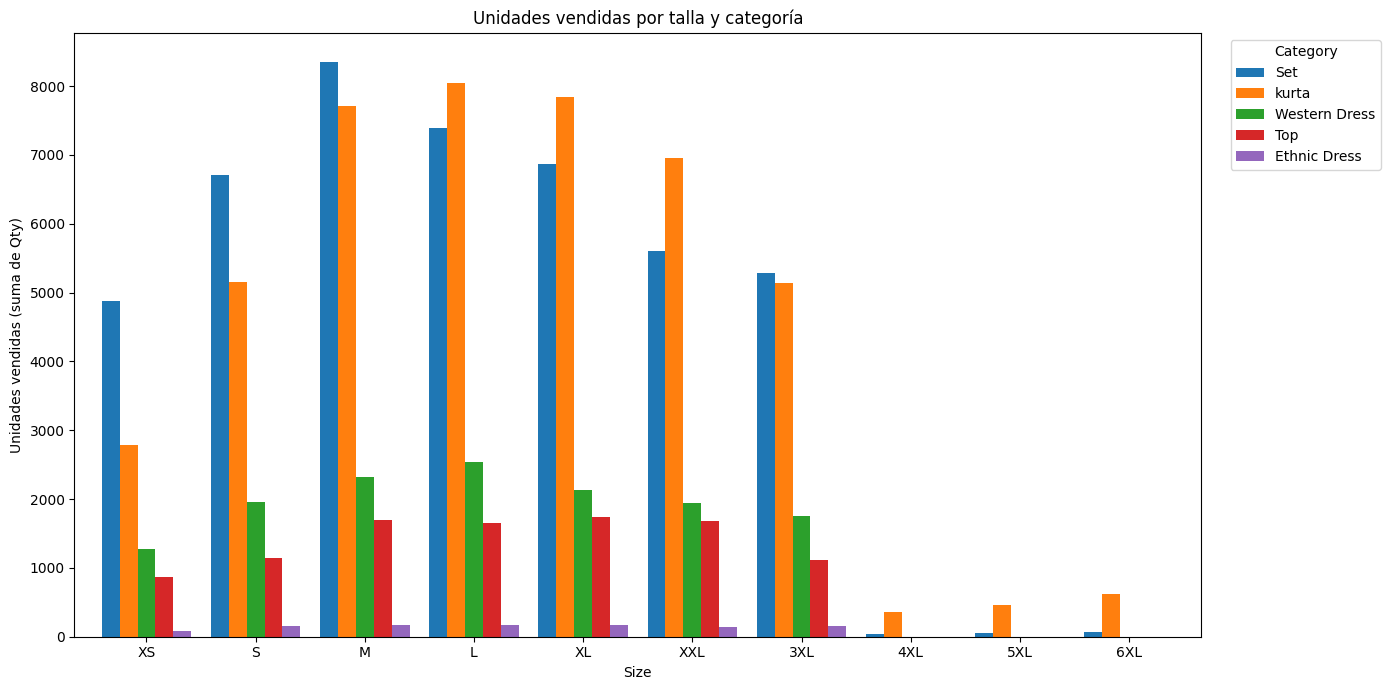

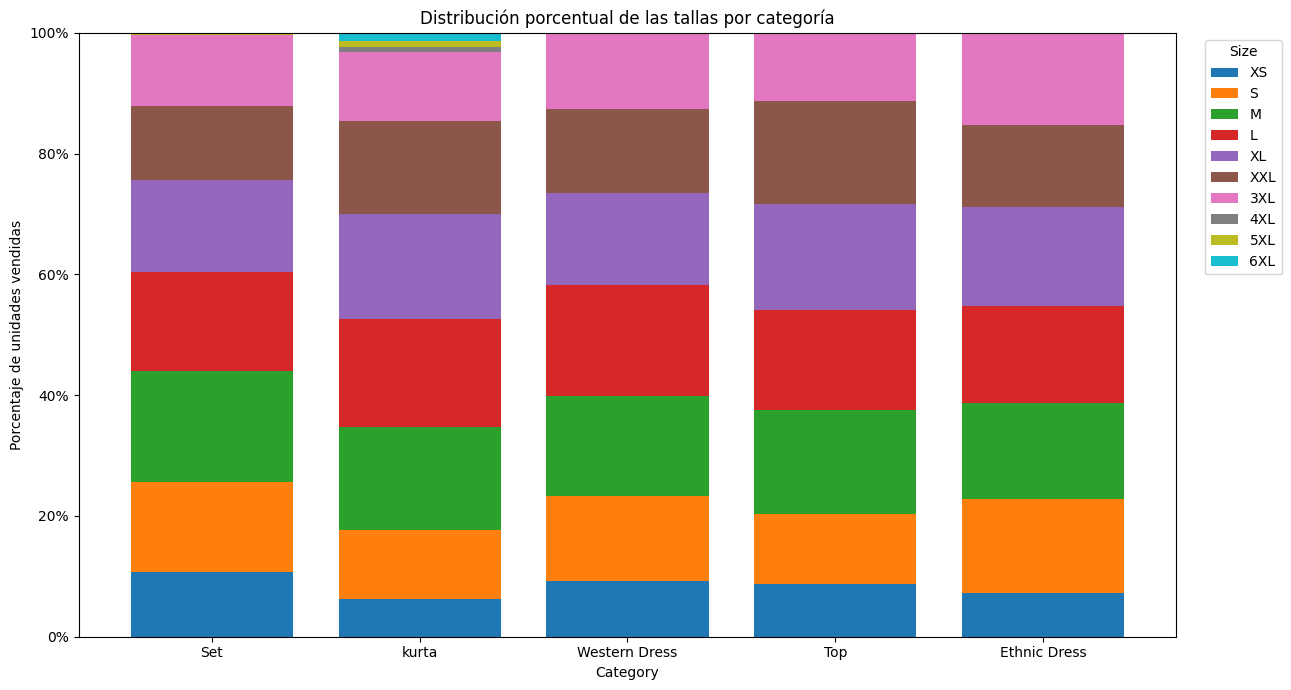


Interpretación basada en las proporciones dentro de cada categoría:
- Set: la talla con mayor participación es M (18.5%).
- kurta: la talla con mayor participación es L (17.9%).
- Western Dress: la talla con mayor participación es L (18.3%).
- Top: la talla con mayor participación es XL (17.5%).
- Ethnic Dress: la talla con mayor participación es XL (16.4%).
- La mayor diferencia para una talla individual se observa en XXL: 17.0% en Top frente a 12.4% en Set (4.7 puntos porcentuales).
- Las tallas 4XL–6XL suman 3.2% en kurta, frente a 0.0% en Western Dress.
Estas diferencias describen la mezcla de unidades vendidas; para inventario, la distribución de tallas puede planificarse por categoría en lugar de aplicar una mezcla uniforme.


In [ ]:
import matplotlib.pyplot as plt

# Normalizar etiquetas y excluir solo categorías, tallas o cantidades inválidas.
datos = df.copy()
datos['Category'] = datos['Category'].astype('string').str.strip()
datos['Size'] = datos['Size'].astype('string').str.strip().str.upper()
datos['Qty_num'] = pd.to_numeric(datos['Qty'], errors='coerce')

tallas_validas = {'XS', 'S', 'M', 'L', 'XL', 'XXL', '3XL', '4XL', '5XL', '6XL', 'FREE'}
mascara_talla = datos['Size'].isin(tallas_validas)
mascara_categoria = datos['Category'].notna() & datos['Category'].ne('')
mascara_qty = datos['Qty_num'].notna() & datos['Qty_num'].ge(0)

print('Tallas no reconocidas excluidas:', sorted(datos.loc[~mascara_talla, 'Size'].dropna().unique().tolist()))
print('Filas excluidas por talla faltante/no reconocida:', int((~mascara_talla).sum()))
print('Filas excluidas por categoría faltante:', int((~mascara_categoria).sum()))
print('Filas excluidas por Qty faltante/no numérica/negativa:', int((~mascara_qty).sum()))

ventas = datos.loc[mascara_talla & mascara_categoria & mascara_qty].copy()
ventas['Size'] = ventas['Size'].replace({'FREE': 'Free'})

unidades_categoria = ventas.groupby('Category')['Qty_num'].sum().sort_values(ascending=False)
categorias_principales = unidades_categoria.head(5).index.tolist()
participacion_principales = unidades_categoria.loc[categorias_principales].sum() / unidades_categoria.sum() * 100
print(f'\nCategorías principales por Qty: {categorias_principales}')
print(f'Participación de estas categorías en las unidades válidas: {participacion_principales:.2f}%')

orden_tallas = ['XS', 'S', 'M', 'L', 'XL', 'XXL', '3XL', '4XL', '5XL', '6XL', 'Free']
ventas_principales = ventas[ventas['Category'].isin(categorias_principales)]
unidades = ventas_principales.pivot_table(
    index='Size', columns='Category', values='Qty_num', aggfunc='sum', fill_value=0
).reindex(orden_tallas, fill_value=0)
unidades = unidades.loc[unidades.sum(axis=1) > 0, categorias_principales]
porcentajes = unidades.div(unidades.sum(axis=0), axis=1).mul(100)

print('\nUnidades vendidas por Category × Size:')
display(unidades.astype(int))
print('\nPorcentaje de cada talla dentro de cada categoría (%):')
display(porcentajes.round(2))

ax = unidades.plot(kind='bar', figsize=(14, 7), width=0.82)
ax.set_title('Unidades vendidas por talla y categoría')
ax.set_xlabel('Size')
ax.set_ylabel('Unidades vendidas (suma de Qty)')
ax.legend(title='Category', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

tallas_presentacion = ['XS', 'S', 'M', 'L', 'XL', 'XXL']
porcentajes_principales = porcentajes.reindex(tallas_presentacion).loc[:, categorias_principales]

print('\nPorcentaje de unidades vendidas por talla y categoría (base: suma de Qty):')
display(porcentajes_principales)

ax = porcentajes_principales.plot(kind='bar', figsize=(13, 7), width=0.82)
ax.set_title('Porcentaje de unidades vendidas por talla y categoría')
ax.set_xlabel('Talla')
ax.set_ylabel('Porcentaje de unidades vendidas')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda valor, posicion: f'{valor:.0f}%'))
ax.legend(title='Categoría', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.tick_params(axis='x', rotation=0)
ax.grid(axis='y', linestyle=':', alpha=0.45)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

print('\nTalla con mayor porcentaje entre XS, S, M, L, XL y XXL en cada categoría:')
modas_principales = porcentajes_principales.idxmax(axis=0)
for categoria in categorias_principales:
    talla_moda = modas_principales[categoria]
    print(f'- {categoria}: {talla_moda} ({porcentajes_principales.loc[talla_moda, categoria]:.2f}%).')

brecha_por_talla = porcentajes_principales.max(axis=1) - porcentajes_principales.min(axis=1)
talla_mayor_brecha = brecha_por_talla.idxmax()
categoria_mayor = porcentajes_principales.loc[talla_mayor_brecha].idxmax()
categoria_menor = porcentajes_principales.loc[talla_mayor_brecha].idxmin()
print(
    f'La mayor diferencia entre categorías dentro de estas tallas se observa en {talla_mayor_brecha}: '
    f'{porcentajes_principales.loc[talla_mayor_brecha, categoria_mayor]:.2f}% en {categoria_mayor} frente a '
    f'{porcentajes_principales.loc[talla_mayor_brecha, categoria_menor]:.2f}% en {categoria_menor} '
    f'({brecha_por_talla[talla_mayor_brecha]:.2f} puntos porcentuales).'
)